In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from prophet import Prophet
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

Importing plotly failed. Interactive plots will not work.


In [4]:
train_df = pd.read_parquet(
    "../data/train_df.parquet"
)

val_df = pd.read_parquet(
    "../data/val_df.parquet"
)

with open(
    "../data/scalers.pkl",
    "rb"
) as f:
    scalers = pickle.load(f)

selected_containers = np.load(
    "../data/selected_containers.npy",
    allow_pickle=True
)

/Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
global_train = train_df[
    train_df["container_id"]
    .isin(selected_containers)
].copy()

global_val = val_df[
    val_df["container_id"]
    .isin(selected_containers)
].copy()

In [6]:
print(global_train.shape)
print(global_val.shape)

(61272, 11)
(15373, 11)


In [7]:
global_model = load_model(
    "../models/hybrid_gru.keras"
)

2026-07-13 13:02:40.991852: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-13 13:02:40.992065: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-13 13:02:40.992087: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-13 13:02:40.992317: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-13 13:02:40.992341: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
with open(
    "../models/residual_stats.pkl",
    "rb"
) as f:
    stats = pickle.load(f)

res_mean = stats["res_mean"]
res_std = stats["res_std"]

In [9]:
target_cid = "c_11461"

In [10]:
train_container = global_train[
    global_train["container_id"] == target_cid
].sort_values("time_stamp")

val_container = global_val[
    global_val["container_id"] == target_cid
].sort_values("time_stamp")

In [11]:
prophet_train = pd.DataFrame({
    "ds": train_container["time_stamp"],
    "y": train_container["cpu_scaled"]
})

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False
)

prophet_model.fit(prophet_train)

13:02:43 - cmdstanpy - INFO - Chain [1] start processing
13:02:43 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future_df = pd.DataFrame({
    "ds": val_container["time_stamp"].values[:192]
})

forecast = prophet_model.predict(
    future_df
)

In [13]:
val_container["prophet_pred"] = (
    forecast["yhat"].values
)

In [14]:
val_container.head()

,container_id,time_stamp,cpu_util_percent,cpu_usage,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour,prophet_pred
2923,c_11461,1970-01-08 09:45:00,22.0,22.0,22.0,0.421875,0.181902,0.135836,1.0,0.0,9,0.382588
2924,c_11461,1970-01-08 10:00:00,23.0,23.0,23.0,0.445312,0.181902,0.135836,1.0,0.0,10,0.382810
2925,c_11461,1970-01-08 10:15:00,NaN,20.5,20.5,0.386719,0.181902,0.135836,1.0,0.0,10,0.379024
2926,c_11461,1970-01-08 10:30:00,18.0,18.0,18.0,0.328125,0.181902,0.135836,1.0,0.0,10,0.371844
2927,c_11461,1970-01-08 10:45:00,19.0,19.0,19.0,0.351562,0.181902,0.135836,1.0,0.0,10,0.362015


In [15]:
train_forecast = prophet_model.predict(
    prophet_train[["ds"]]
)

train_container["prophet_pred"] = (
    train_forecast["yhat"].values
)

train_container["residual"] = (
    train_container["cpu_scaled"]
    - train_container["prophet_pred"]
)

train_container["residual_scaled"] = (
    train_container["residual"] - res_mean
) / res_std

In [16]:
residual_input = (
    train_container["residual_scaled"]
    .values[-288:]
)

In [17]:
X_input = np.column_stack([
    residual_input
])

X_input = X_input.reshape(
    1,
    288,
    1
)

In [18]:
day1_residual_scaled = global_model.predict(
    X_input
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


2026-07-13 13:02:47.214787: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [19]:
day1_residual = (
    day1_residual_scaled * res_std
) + res_mean
day1_residual.size

96

In [20]:
day1_prophet = (
    forecast["yhat"]
    .values[:96]
)
day1_prophet.size

96

In [21]:
day1_final_scaled = (
    day1_prophet + day1_residual
)

In [22]:
day1_final_scaled = (
    day1_prophet + day1_residual
)

In [23]:
day2_input_residuals = np.concatenate([
    residual_input[96:],   # keep latest 192
    day1_residual_scaled                 # append predicted day1
])

X_day2 = day2_input_residuals.reshape(
    1,
    288,
    1
)

In [24]:
day2_residual_scaled = global_model.predict(
    X_day2
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [25]:
day2_residual = (
    day2_residual_scaled * res_std
) + res_mean
day2_residual.size

96

In [26]:
day2_prophet = (
    forecast["yhat"]
    .values[96:192]
)
day2_prophet.size

57

In [27]:
available_len = len(day2_prophet)

day2_final_scaled = (
    day2_prophet
    + day2_residual[:available_len]
)
day2_final_scaled.size

57

In [28]:
actual_day1_scaled = (
    val_container["cpu_scaled"]
    .values[:96]
)

In [29]:
actual_day2_scaled = (
    val_container["cpu_scaled"]
     .values[96:96 + available_len]
)

In [30]:
scaler = scalers[target_cid]

# DAY 1
day1_final_real = scaler.inverse_transform(
    day1_final_scaled.reshape(-1,1)
)

actual_day1_real = scaler.inverse_transform(
    actual_day1_scaled.reshape(-1,1)
)

prophet_day1_real = scaler.inverse_transform(
    day1_prophet.reshape(-1,1)
)

# DAY 2
day2_final_real = scaler.inverse_transform(
    day2_final_scaled.reshape(-1,1)
)

actual_day2_real = scaler.inverse_transform(
    actual_day2_scaled.reshape(-1,1)
)

prophet_day2_real = scaler.inverse_transform(
    day2_prophet.reshape(-1,1)
)


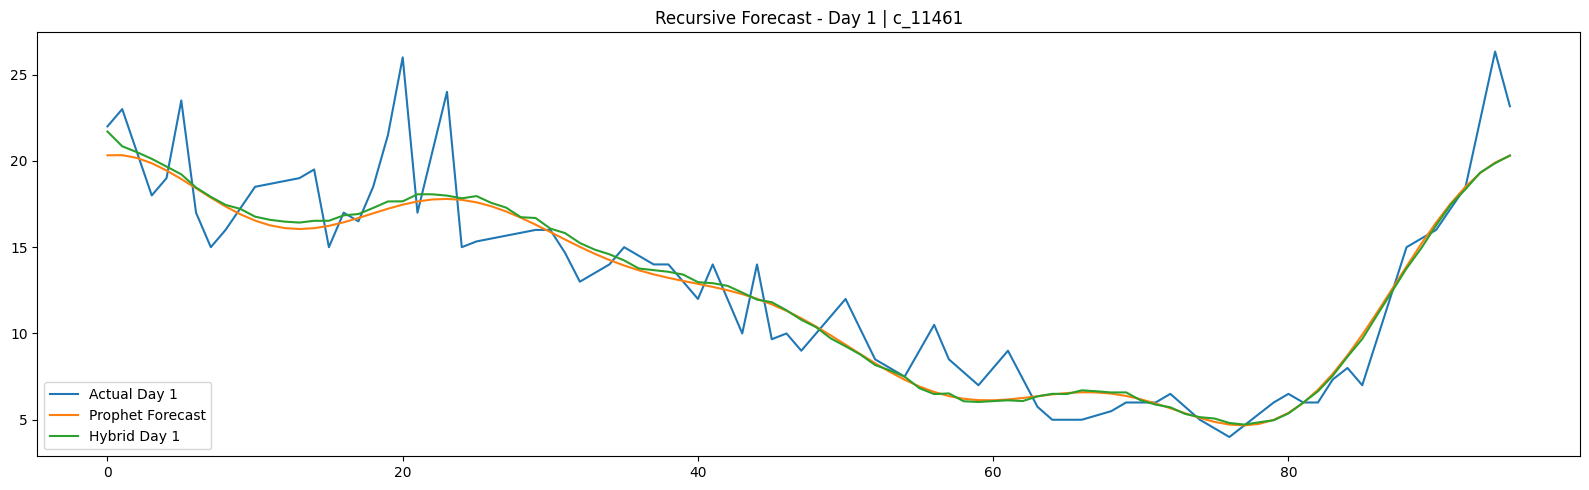

In [31]:
plt.figure(figsize=(16,5))

plt.plot(
    actual_day1_real,
    label="Actual Day 1"
)
plt.plot(
    prophet_day1_real,
    label="Prophet Forecast"
)
plt.plot(
    day1_final_real,
    label="Hybrid Day 1"
)
plt.title(
    f"Recursive Forecast - Day 1 | {target_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()

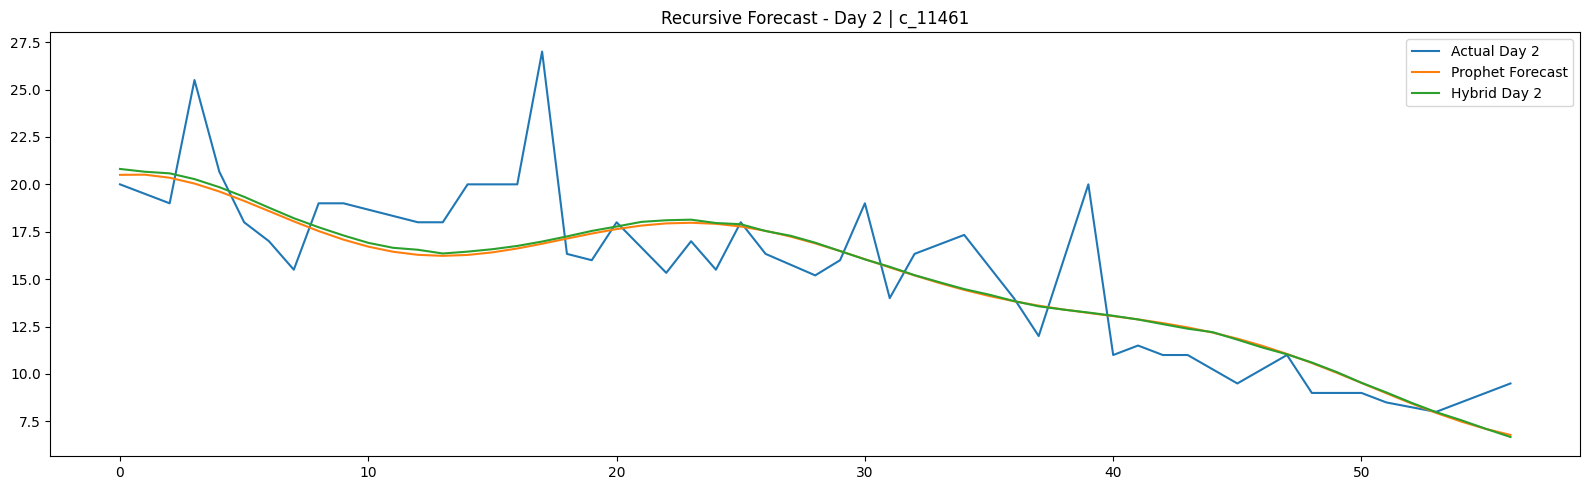

In [32]:
plt.figure(figsize=(16,5))

plt.plot(
    actual_day2_real,
    label="Actual Day 2"
)
plt.plot(
    prophet_day2_real,
    label="Prophet Forecast"
)
plt.plot(
    day2_final_real,
    label="Hybrid Day 2"
)
plt.title(
    f"Recursive Forecast - Day 2 | {target_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
day1_mae = mean_absolute_error(
    actual_day1_real,
    day1_final_real
)
day1_rmse = np.sqrt(
    mean_squared_error(
        actual_day1_real,
        day1_final_real
    )
)
# DAY 2
day2_mae = mean_absolute_error(
    actual_day2_real,
    day2_final_real
)
day2_rmse = np.sqrt(
    mean_squared_error(
        actual_day2_real,
        day2_final_real
    )
)

print(f"\nDay 1 MAE  : {day1_mae:.4f}")
print(f"Day 1 RMSE : {day1_rmse:.4f}")
print(f"\nDay 2 MAE  : {day2_mae:.4f}")
print(f"Day 2 RMSE : {day2_rmse:.4f}")


Day 1 MAE  : 1.4712
Day 1 RMSE : 2.0333

Day 2 MAE  : 1.8476
Day 2 RMSE : 2.4506
